# Context Aware Nutritional Assessment
## Predicting Food Processing Tiers through Machine Learning

### Exploratory Data Analysis
**AAI-590 Capstone Project**

In [45]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries and Configuration

In [46]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.3f}".format)
np.random.seed(42)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (12, 5)})

META_COLS = [
    "code", "product_name", "brands", "categories_en",
    "countries_en", "pnns_groups_1", "pnns_groups_2",
    "nutrition_grade_fr",
    "additives_n", "additives_tags", "ingredients_text",
]

NUTRIENT_COLS = [
    "energy_100g", "fat_100g", "saturated-fat_100g",
    "carbohydrates_100g", "sugars_100g", "fiber_100g",
    "proteins_100g", "salt_100g", "sodium_100g",
]

ALL_COLS = META_COLS + NUTRIENT_COLS

DATASET_PATH = os.path.join("dataset", "en.openfoodfacts.org.products.tsv")


## 2. Load and Inspect Dataset

In [47]:
NROWS = 1_000_000

df = pd.read_csv(
    DATASET_PATH,
    sep="\t",
    low_memory=False,
    usecols=lambda c: c in ALL_COLS,
    #nrows=NROWS,
    on_bad_lines="skip",
)

for col in NUTRIENT_COLS + ["additives_n"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Shape: {df.shape}")
print(f"\nNutri-Score distribution:\n{df['nutrition_grade_fr'].value_counts().sort_index()}")
df.head(3)


Shape: (356027, 20)

Nutri-Score distribution:
nutrition_grade_fr
a    40304
b    39010
c    52870
d    72436
e    50236
Name: count, dtype: int64


,code,product_name,brands,categories_en,countries_en,ingredients_text,additives_n,additives_tags,nutrition_grade_fr,pnns_groups_1,pnns_groups_2,energy_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,salt_100g,sodium_100g
0,0000000003087,Farine de blé noir,Ferme t'y R'nao,NaN,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0000000004530,Banana Chips Sweetened (Whole),NaN,NaN,United States,"Bananas, vegetable oil (coconut oil, corn oil ...",0.000,NaN,d,NaN,NaN,2243.000,28.570,28.570,64.290,14.290,3.600,3.570,0.000,0.000
2,0000000004559,Peanuts,Torn & Glasser,NaN,United States,"Peanuts, wheat flour, sugar, rice flour, tapio...",0.000,NaN,b,NaN,NaN,1941.000,17.860,0.000,60.710,17.860,7.100,17.860,0.635,0.250


In [48]:
df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356027 entries, 0 to 356026
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   code                356001 non-null  object 
 1   product_name        338515 non-null  object 
 2   brands              326977 non-null  object 
 3   categories_en       103301 non-null  object 
 4   countries_en        355752 non-null  object 
 5   ingredients_text    283893 non-null  object 
 6   additives_n         283867 non-null  float64
 7   additives_tags      170189 non-null  object 
 8   nutrition_grade_fr  254856 non-null  object 
 9   pnns_groups_1       129006 non-null  object 
 10  pnns_groups_2       132689 non-null  object 
 11  energy_100g         295367 non-null  float64
 12  fat_100g            279497 non-null  float64
 13  saturated-fat_100g  263823 non-null  float64
 14  carbohydrates_100g  279220 non-null  float64
 15  sugars_100g         279186 non-nul

In [49]:
df[NUTRIENT_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
energy_100g,295367.000,1125.450,936.830,0.000,382.000,1092.000,1674.000,231199.000
fat_100g,279497.000,56065.870,29633845.280,0.000,0.100,5.290,20.000,15666666000.000
saturated-fat_100g,263823.000,5.090,7.970,0.000,0.000,1.790,7.140,550.000
carbohydrates_100g,279220.000,56140.200,29648540.710,0.000,5.600,20.000,57.580,15666666000.000
sugars_100g,279186.000,15.670,21.980,-17.860,1.200,5.400,23.330,3520.000
fiber_100g,220683.000,384346.730,180552853.310,-6.700,0.000,1.500,3.600,84818150000.000
proteins_100g,294161.000,53265.980,28885775.920,-800.000,0.720,4.880,10.000,15666666000.000
salt_100g,289739.000,1.940,120.550,0.000,0.060,0.560,1.360,64312.800
sodium_100g,289694.000,0.760,47.460,0.000,0.020,0.220,0.530,25320.000


## 3. Data Quality Assessment

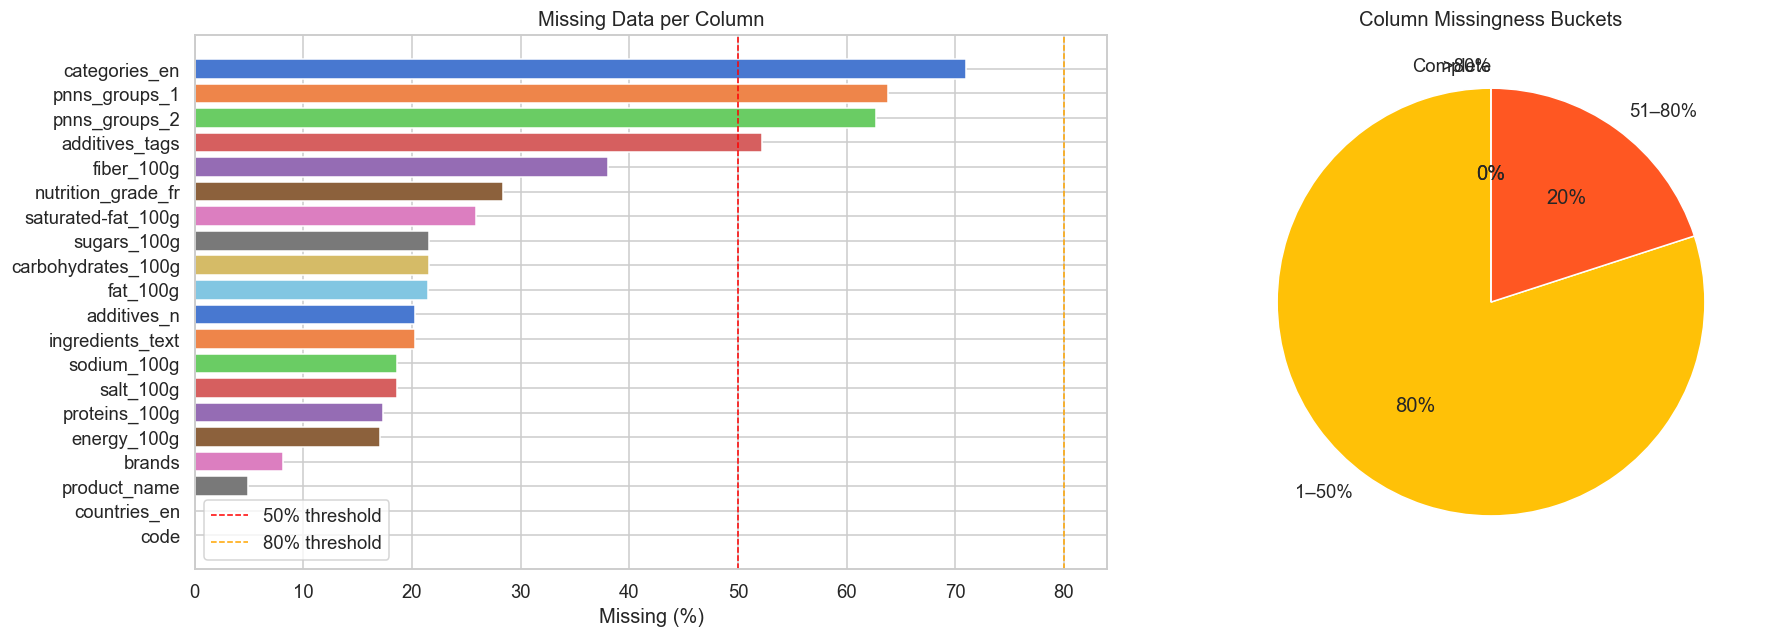

Duplicate rows       : 2
Columns >50% missing : 4
Columns >80% missing : 0


In [ ]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_df = missing.reset_index()
missing_df.columns = ["column", "missing_pct"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].barh(missing_df["column"], missing_df["missing_pct"], color=sns.color_palette("muted"))
axes[0].axvline(50, color="red", linestyle="--", linewidth=1, label="50% threshold")
axes[0].axvline(80, color="orange", linestyle="--", linewidth=1, label="80% threshold")
axes[0].set_xlabel("Missing (%)")
axes[0].set_title("Missing Data per Column")
axes[0].legend()
axes[0].invert_yaxis()

buckets = [
    (missing_df["missing_pct"] == 0).sum(),
    ((missing_df["missing_pct"] > 0) & (missing_df["missing_pct"] <= 50)).sum(),
    ((missing_df["missing_pct"] > 50) & (missing_df["missing_pct"] <= 80)).sum(),
    (missing_df["missing_pct"] > 80).sum(),
]
labels = ["Complete", "1-50%", "51-80%", ">80%"]
axes[1].pie(buckets, labels=labels, autopct="%1.0f%%", startangle=90,
            colors=["#4CAF50", "#FFC107", "#FF5722", "#F44336"])
axes[1].set_title("Column Missingness Buckets")

plt.tight_layout()
plt.show()

print(f"Duplicate rows       : {df.duplicated().sum()}")
print(f"Columns >50% missing : {(missing > 50).sum()}")
print(f"Columns >80% missing : {(missing > 80).sum()}")


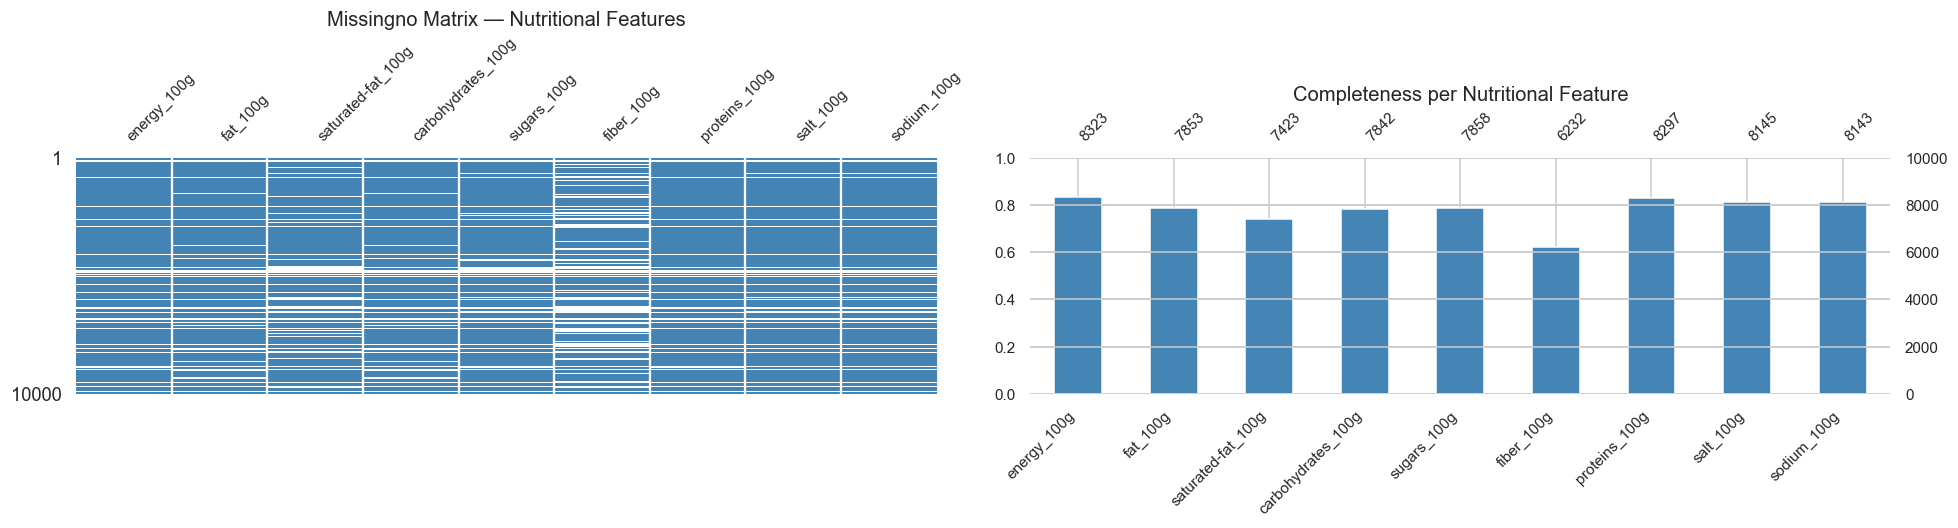

In [51]:
sample_miss = df[NUTRIENT_COLS].sample(min(10_000, len(df)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
msno.matrix(sample_miss, ax=axes[0], sparkline=False, fontsize=10, color=(0.27, 0.52, 0.71))
axes[0].set_title("Missingno Matrix — Nutritional Features")
msno.bar(sample_miss, ax=axes[1], fontsize=10, color=(0.27, 0.52, 0.71))
axes[1].set_title("Completeness per Nutritional Feature")
plt.tight_layout()
plt.show()


## 4. Target Variable Analysis: Nutritional Quality


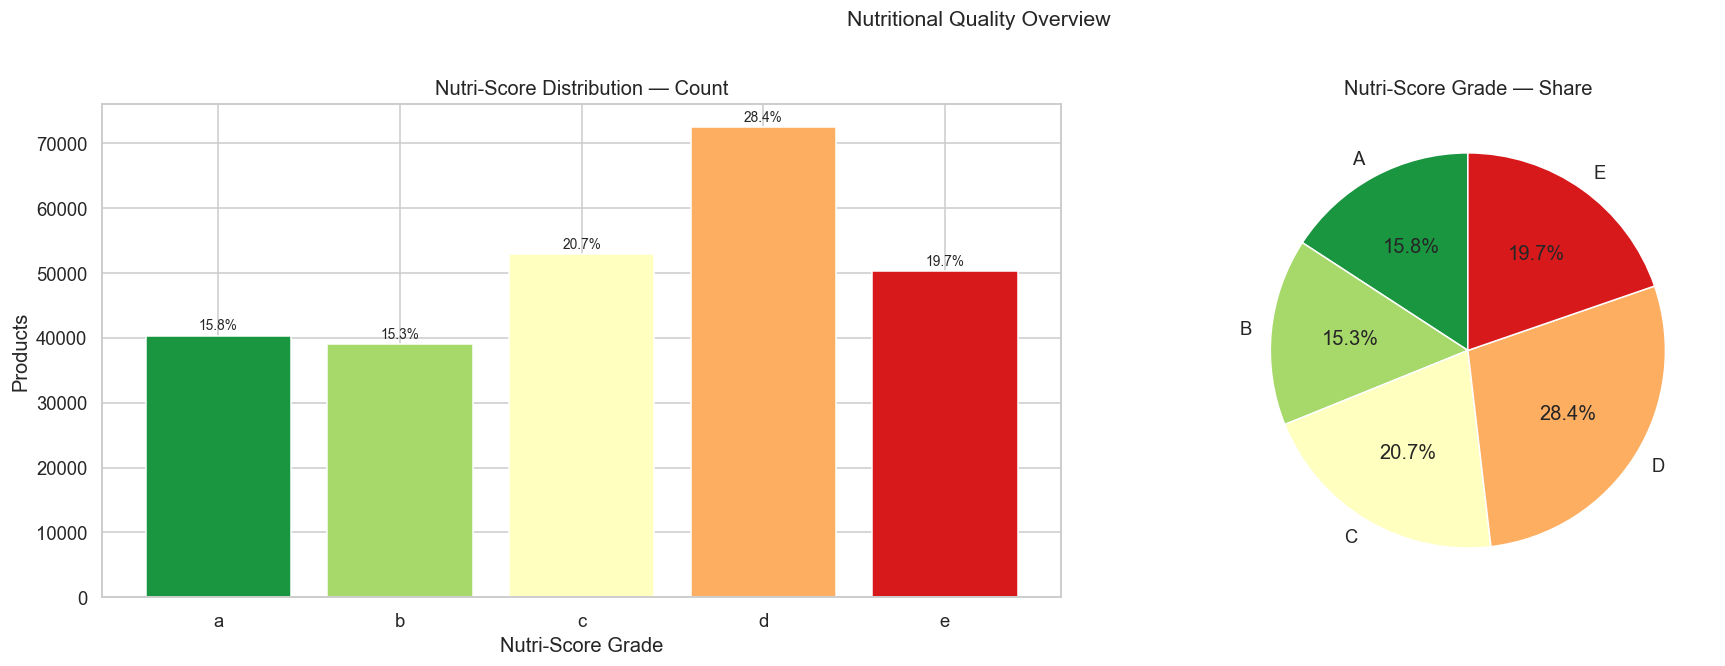

Nutri-Score coverage: 71.6% of loaded rows


In [52]:
grade_order = ["a", "b", "c", "d", "e"]
grade_counts = df["nutrition_grade_fr"].str.lower().value_counts().reindex(grade_order, fill_value=0)
grade_pct = grade_counts / grade_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

bars = axes[0].bar(
    grade_counts.index,
    grade_counts.values,
    color=["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"],
    edgecolor="white",
)
for bar, pct in zip(bars, grade_pct):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)
axes[0].set_title("Nutri-Score Distribution — Count")
axes[0].set_ylabel("Products")
axes[0].set_xlabel("Nutri-Score Grade")

axes[1].pie(
    grade_counts.values,
    labels=grade_counts.index.str.upper(),
    autopct="%1.1f%%",
    colors=["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"],
    startangle=90,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
axes[1].set_title("Nutri-Score Grade — Share")

plt.suptitle("Nutritional Quality Overview", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Nutri-Score coverage: {grade_counts.sum() / len(df) * 100:.1f}% of loaded rows")


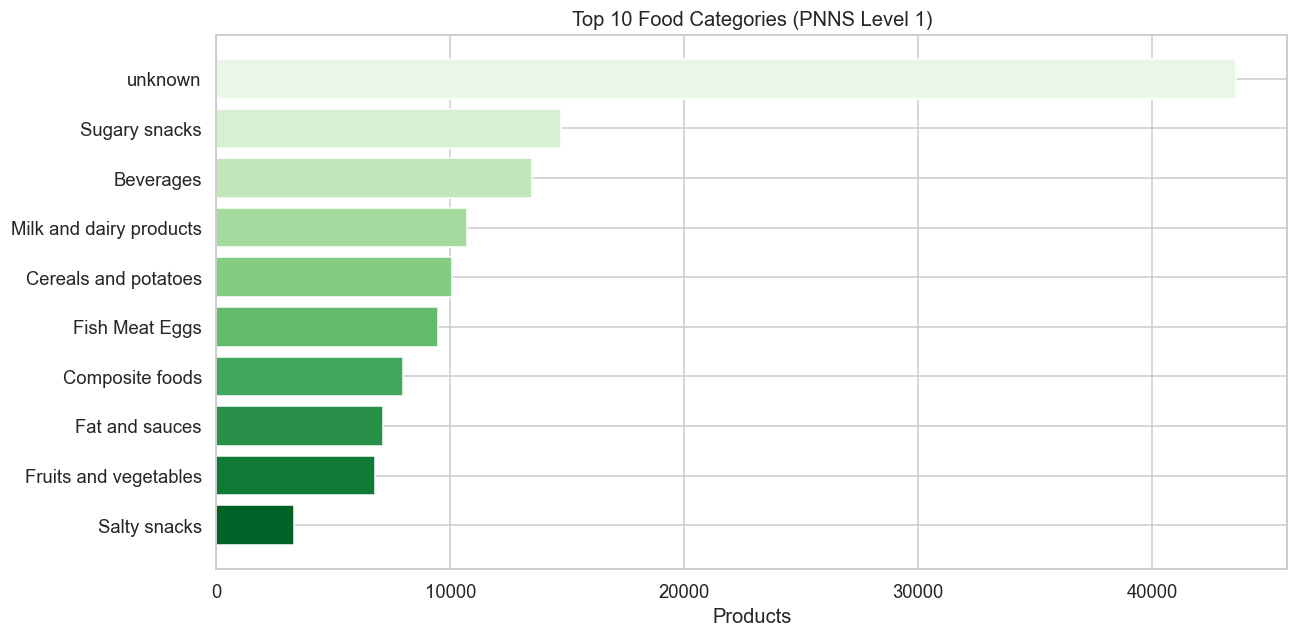

In [53]:
pnns_counts = df["pnns_groups_1"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(pnns_counts.index[::-1], pnns_counts.values[::-1],
        color=sns.color_palette("Greens_r", 10), edgecolor="white")
ax.set_xlabel("Products")
ax.set_title("Top 10 Food Categories (PNNS Level 1)")
plt.tight_layout()
plt.show()


## 5. Nutritional Feature Distributions

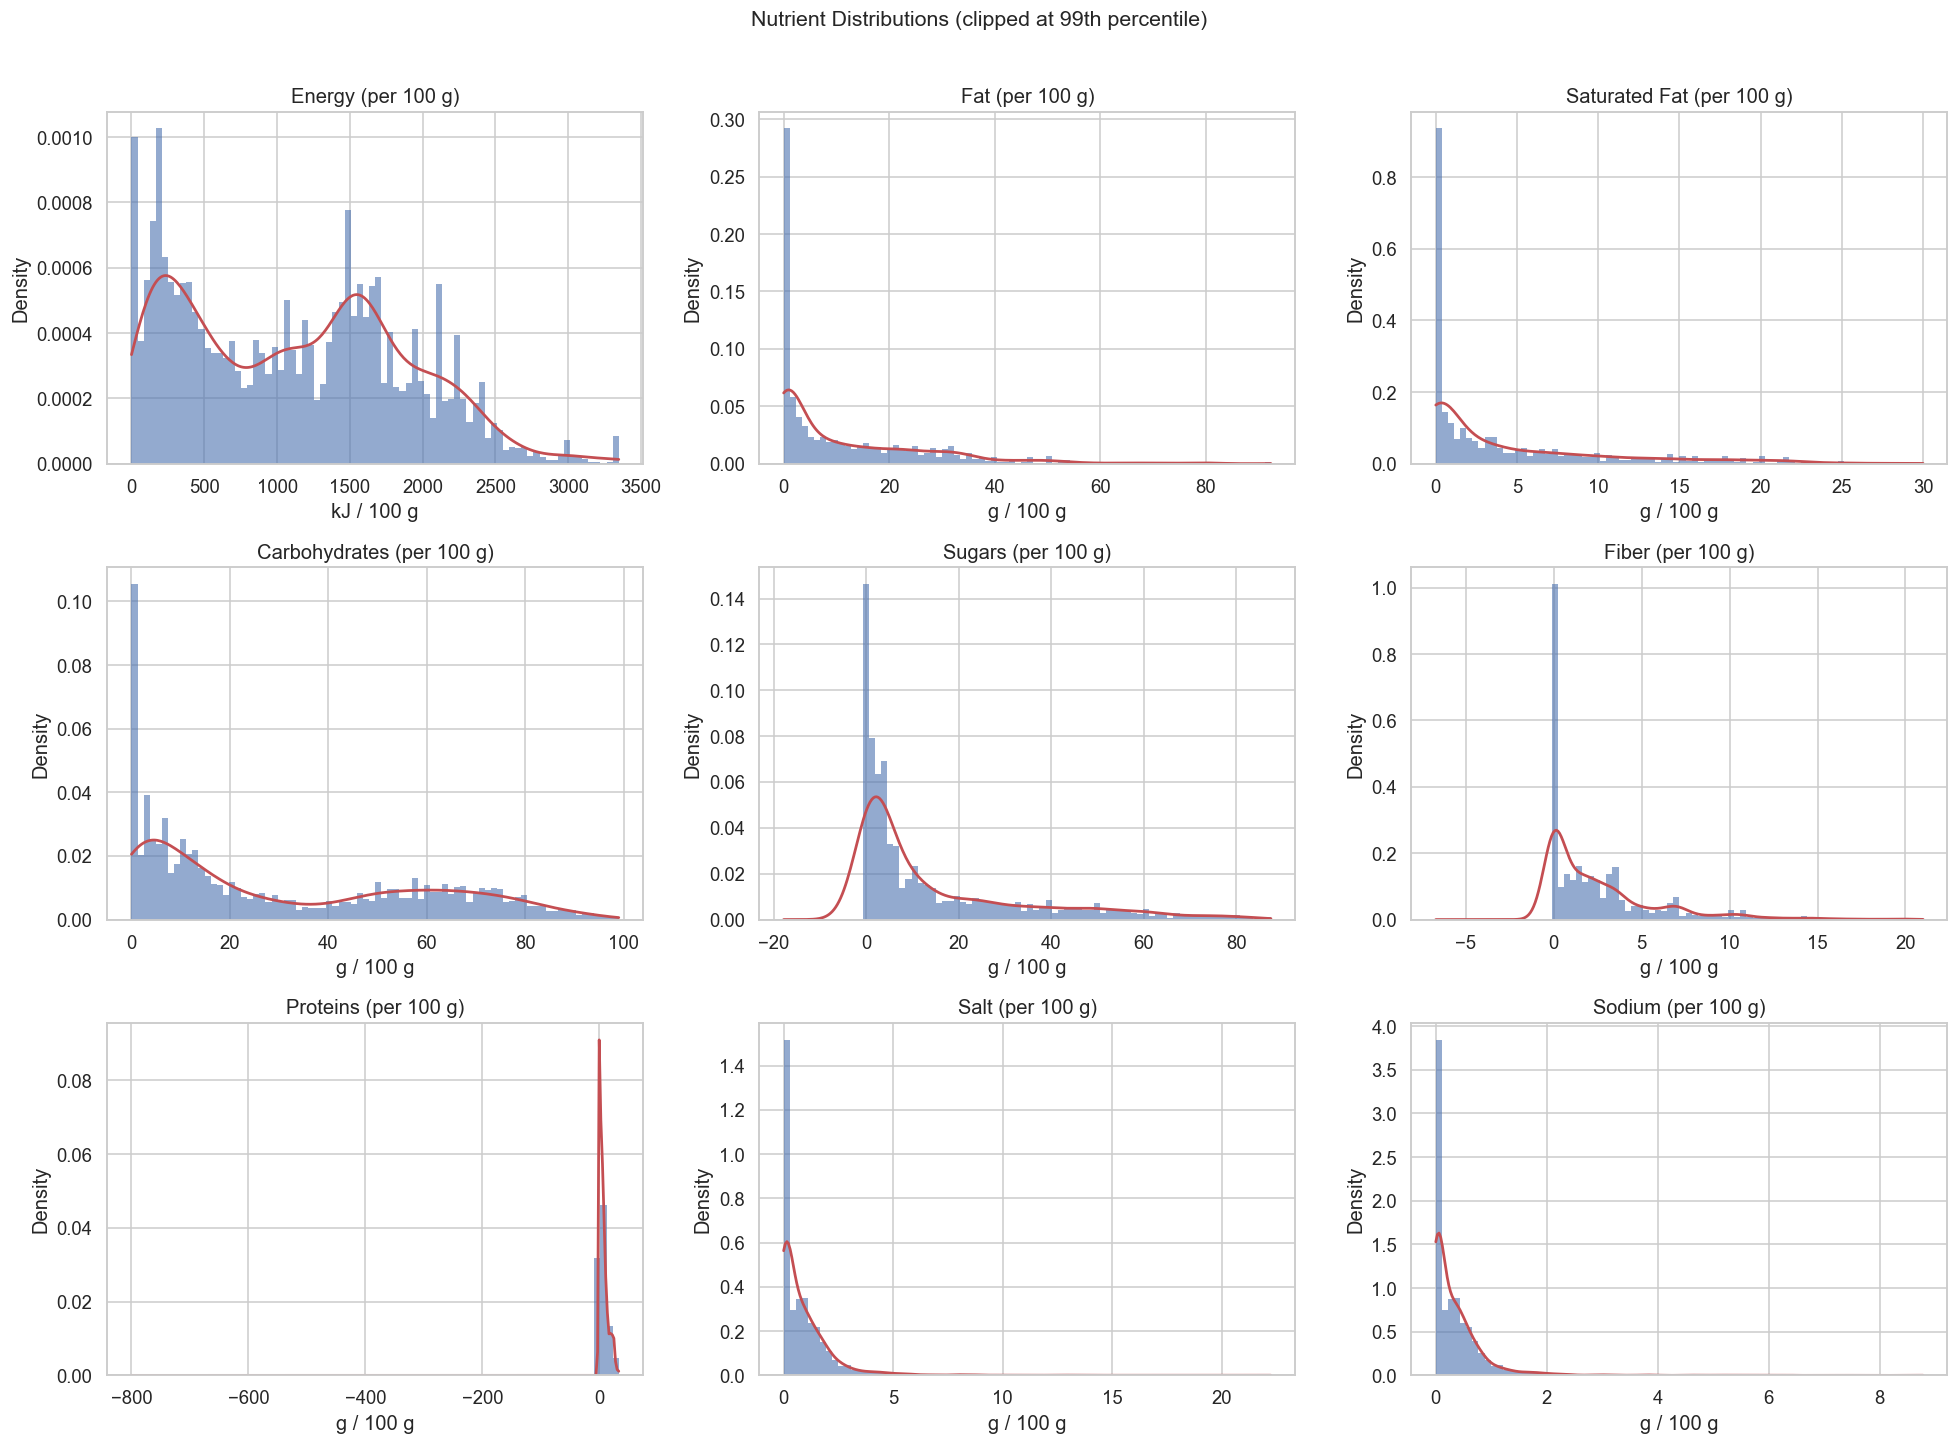

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.ravel()

for i, col in enumerate(NUTRIENT_COLS):
    data = df[col].dropna()
    upper = data.quantile(0.99)
    data_clipped = data[data <= upper]
    axes[i].hist(data_clipped, bins=80, density=True, color="#4C72B0", alpha=0.6, edgecolor="none")
    try:
        kde_x = np.linspace(data_clipped.min(), data_clipped.max(), 300)
        kde = stats.gaussian_kde(data_clipped.sample(min(5000, len(data_clipped)), random_state=42))
        axes[i].plot(kde_x, kde(kde_x), color="#C44E52", linewidth=1.8)
    except Exception:
        pass
    axes[i].set_title(col.replace("_100g", "").replace("-", " ").title() + " (per 100 g)")
    axes[i].set_xlabel("g / 100 g" if col != "energy_100g" else "kJ / 100 g")
    axes[i].set_ylabel("Density")

plt.suptitle("Nutrient Distributions (clipped at 99th percentile)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


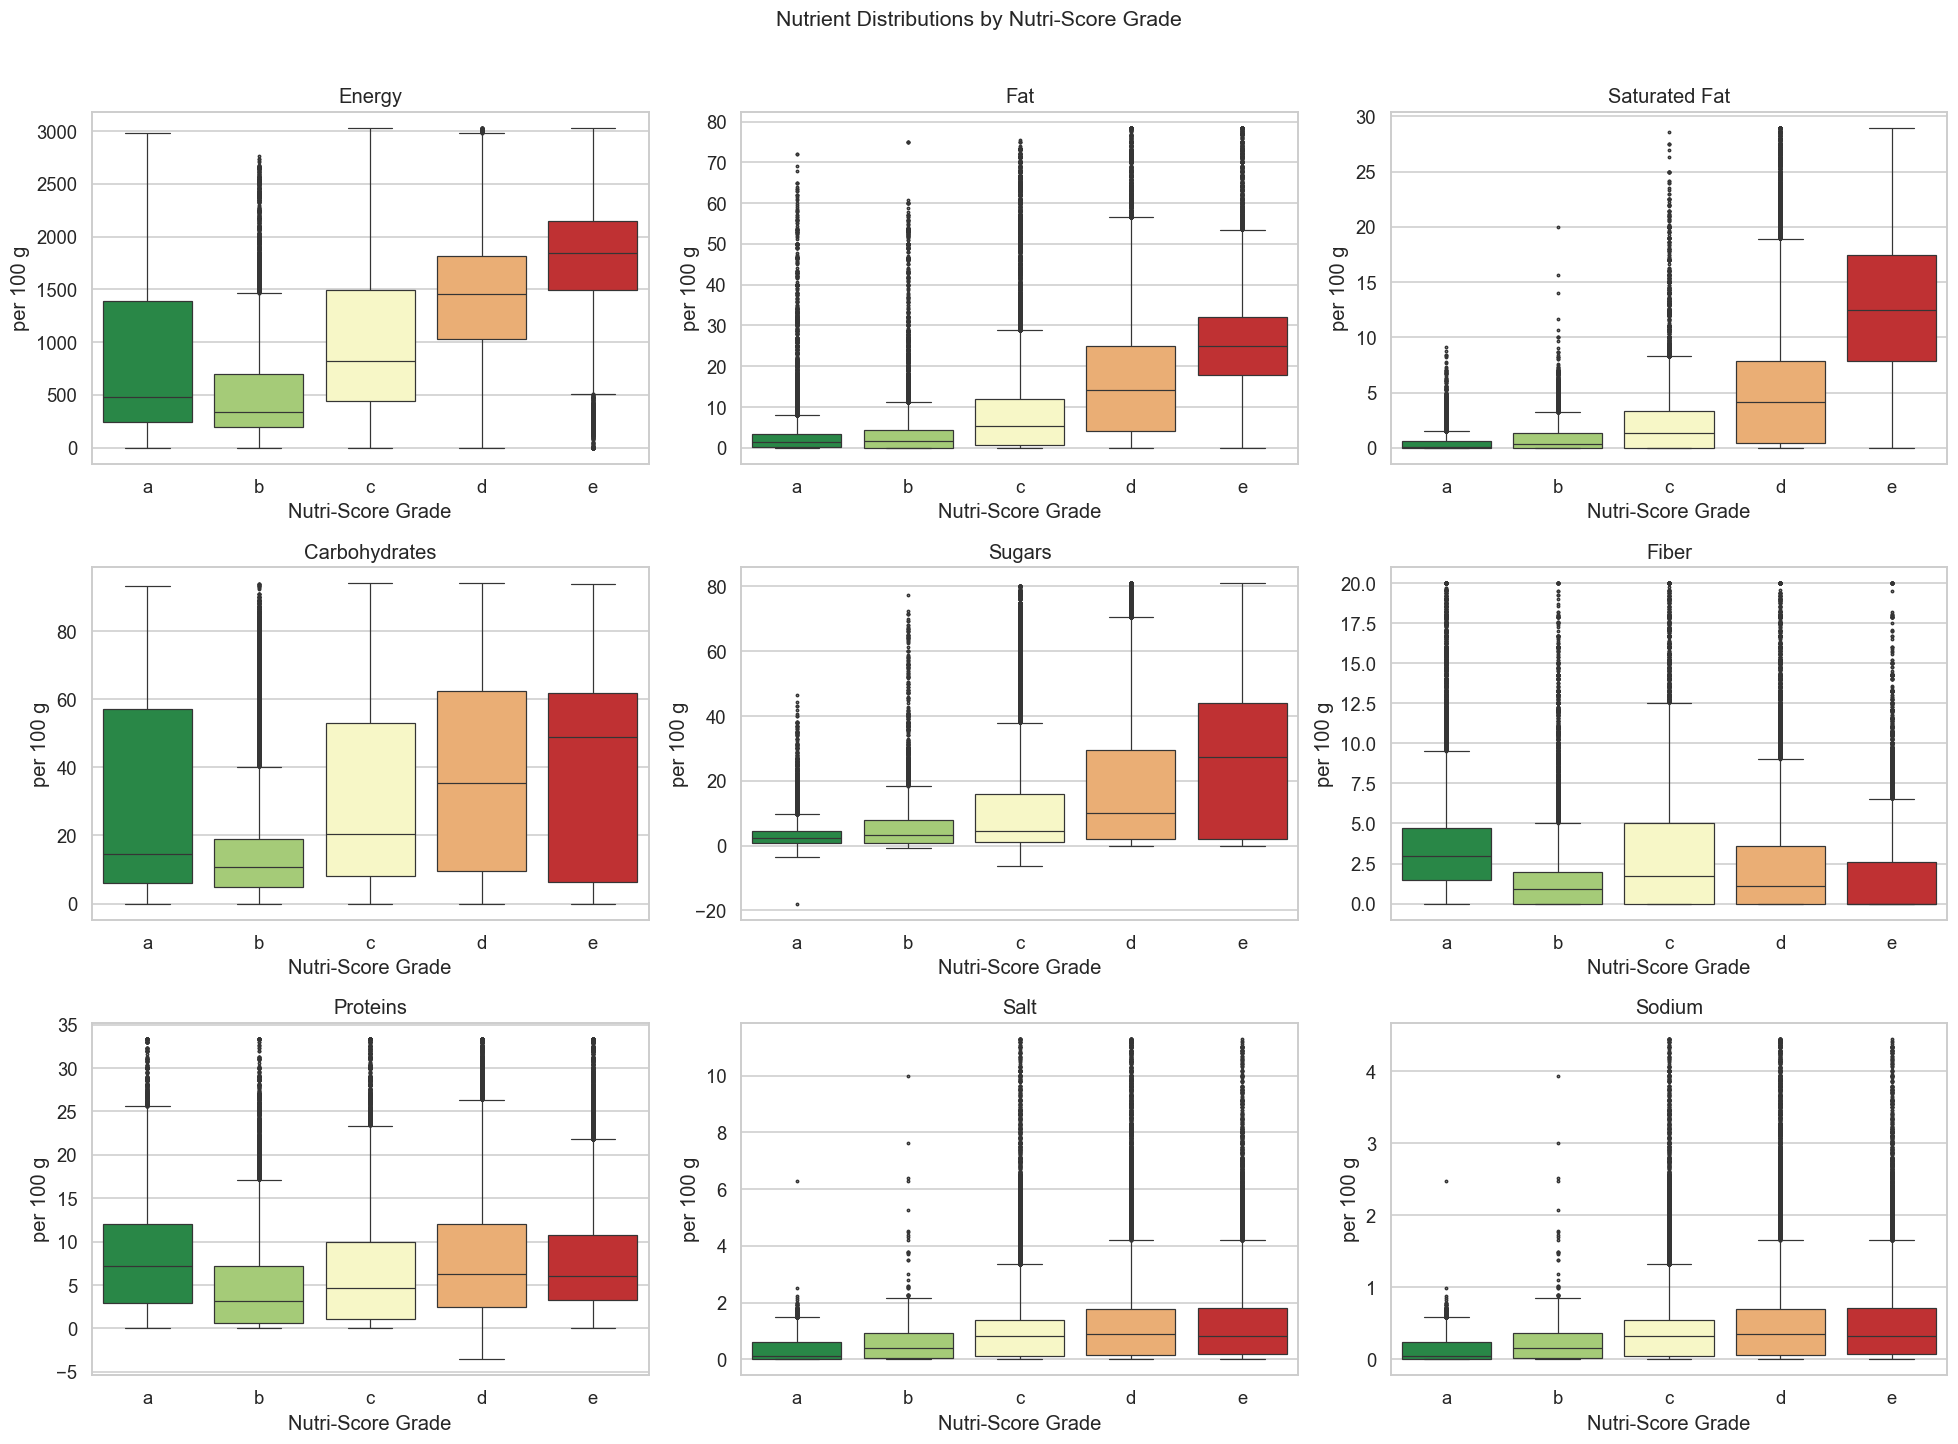

In [55]:
nutriscore_df = df[df["nutrition_grade_fr"].notna()].copy()
nutriscore_df["nutrition_grade_fr"] = nutriscore_df["nutrition_grade_fr"].str.lower()

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.ravel()
palette_nutri = dict(zip(["a", "b", "c", "d", "e"],
                         ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]))

for i, col in enumerate(NUTRIENT_COLS):
    upper = nutriscore_df[col].quantile(0.99)
    plot_data = nutriscore_df[nutriscore_df[col] <= upper]
    sns.boxplot(
        data=plot_data, x="nutrition_grade_fr", y=col, order=["a", "b", "c", "d", "e"],
        palette=palette_nutri, fliersize=1.5, linewidth=0.8, ax=axes[i],
    )
    axes[i].set_title(col.replace("_100g", "").replace("-", " ").title())
    axes[i].set_xlabel("Nutri-Score Grade")
    axes[i].set_ylabel("per 100 g")

plt.suptitle("Nutrient Distributions by Nutri-Score Grade", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 6. Correlation and Multicollinearity Analysis

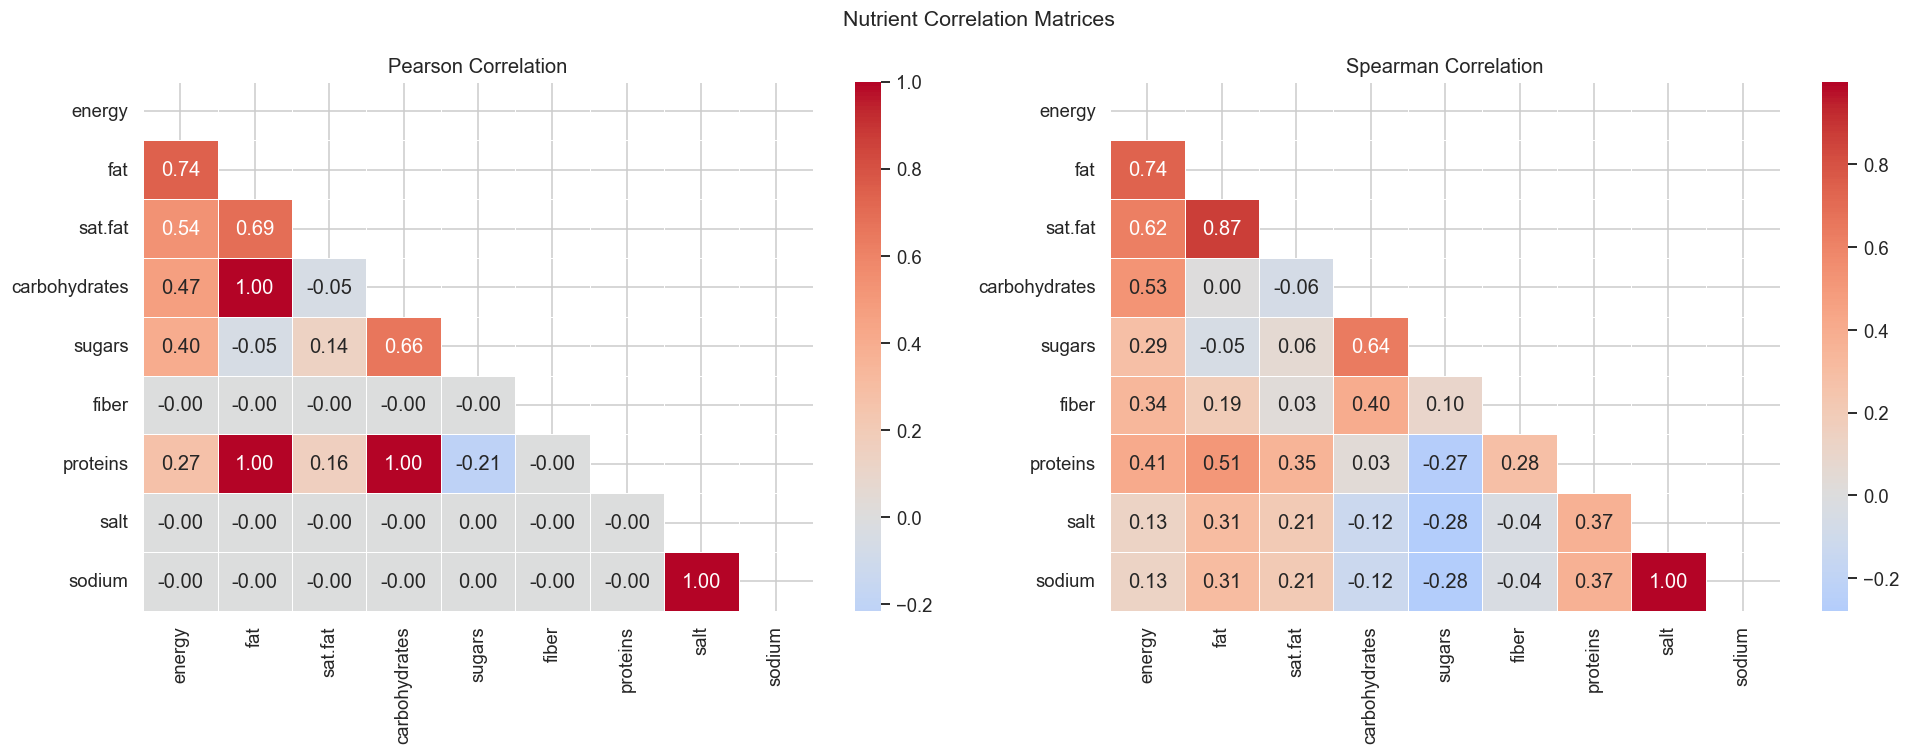

,Feature A,Feature B,Pearson r
0,fat_100g,carbohydrates_100g,1.000
1,fat_100g,proteins_100g,1.000
2,carbohydrates_100g,proteins_100g,1.000
3,salt_100g,sodium_100g,1.000


In [56]:
nutrient_data = df[NUTRIENT_COLS].dropna(how="all")

pearson  = nutrient_data.corr(method="pearson")
spearman = nutrient_data.corr(method="spearman")

short_names = [c.replace("_100g", "").replace("saturated-fat", "sat.fat") for c in NUTRIENT_COLS]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

mask = np.triu(np.ones_like(pearson, dtype=bool))

sns.heatmap(pearson.rename(index=dict(zip(NUTRIENT_COLS, short_names)),
                           columns=dict(zip(NUTRIENT_COLS, short_names))),
            annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, linewidths=0.4, ax=axes[0])
axes[0].set_title("Pearson Correlation")

sns.heatmap(spearman.rename(index=dict(zip(NUTRIENT_COLS, short_names)),
                            columns=dict(zip(NUTRIENT_COLS, short_names))),
            annot=True, fmt=".2f", cmap="coolwarm", center=0,
            mask=mask, linewidths=0.4, ax=axes[1])
axes[1].set_title("Spearman Correlation")

plt.suptitle("Nutrient Correlation Matrices", fontsize=14)
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(NUTRIENT_COLS)):
    for j in range(i + 1, len(NUTRIENT_COLS)):
        r = pearson.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((NUTRIENT_COLS[i], NUTRIENT_COLS[j], round(r, 3)))

if high_corr:
    hc_df = pd.DataFrame(high_corr, columns=["Feature A", "Feature B", "Pearson r"])
    display(hc_df)
else:
    print("No pairs exceed |r| = 0.85.")


## 7. Additive and Ingredient Analysis

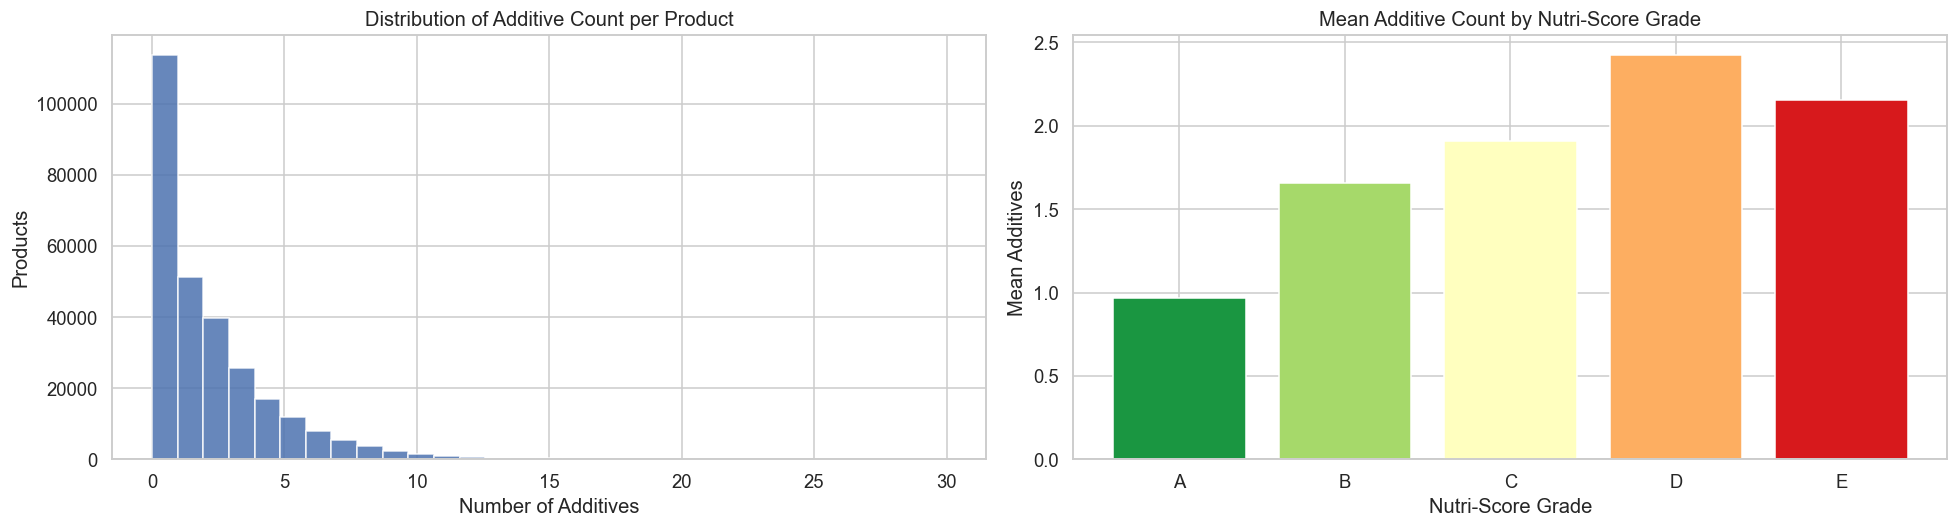

In [57]:
if "additives_n" in df.columns:
    add_counts = df["additives_n"].dropna()
else:
    add_counts = df["additives_tags"].dropna().apply(
        lambda x: len(str(x).split(",")) if pd.notna(x) else 0
    )

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].hist(add_counts.clip(upper=30), bins=31, range=(0, 30),
             color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribution of Additive Count per Product")
axes[0].set_xlabel("Number of Additives")
axes[0].set_ylabel("Products")
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(5))

nutri_df_temp = df[df["nutrition_grade_fr"].notna()].copy()
nutri_df_temp["nutrition_grade_fr"] = nutri_df_temp["nutrition_grade_fr"].str.lower()
nutri_add = (
    nutri_df_temp.assign(additives_n=pd.to_numeric(nutri_df_temp.get("additives_n", pd.Series(dtype=float)), errors="coerce"))
           .groupby("nutrition_grade_fr")["additives_n"]
           .mean()
           .reindex(["a", "b", "c", "d", "e"])
)
bar_colors = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]
axes[1].bar(nutri_add.index.str.upper(), nutri_add.values, color=bar_colors, edgecolor="white")
axes[1].set_title("Mean Additive Count by Nutri-Score Grade")
axes[1].set_xlabel("Nutri-Score Grade")
axes[1].set_ylabel("Mean Additives")

plt.tight_layout()
plt.show()


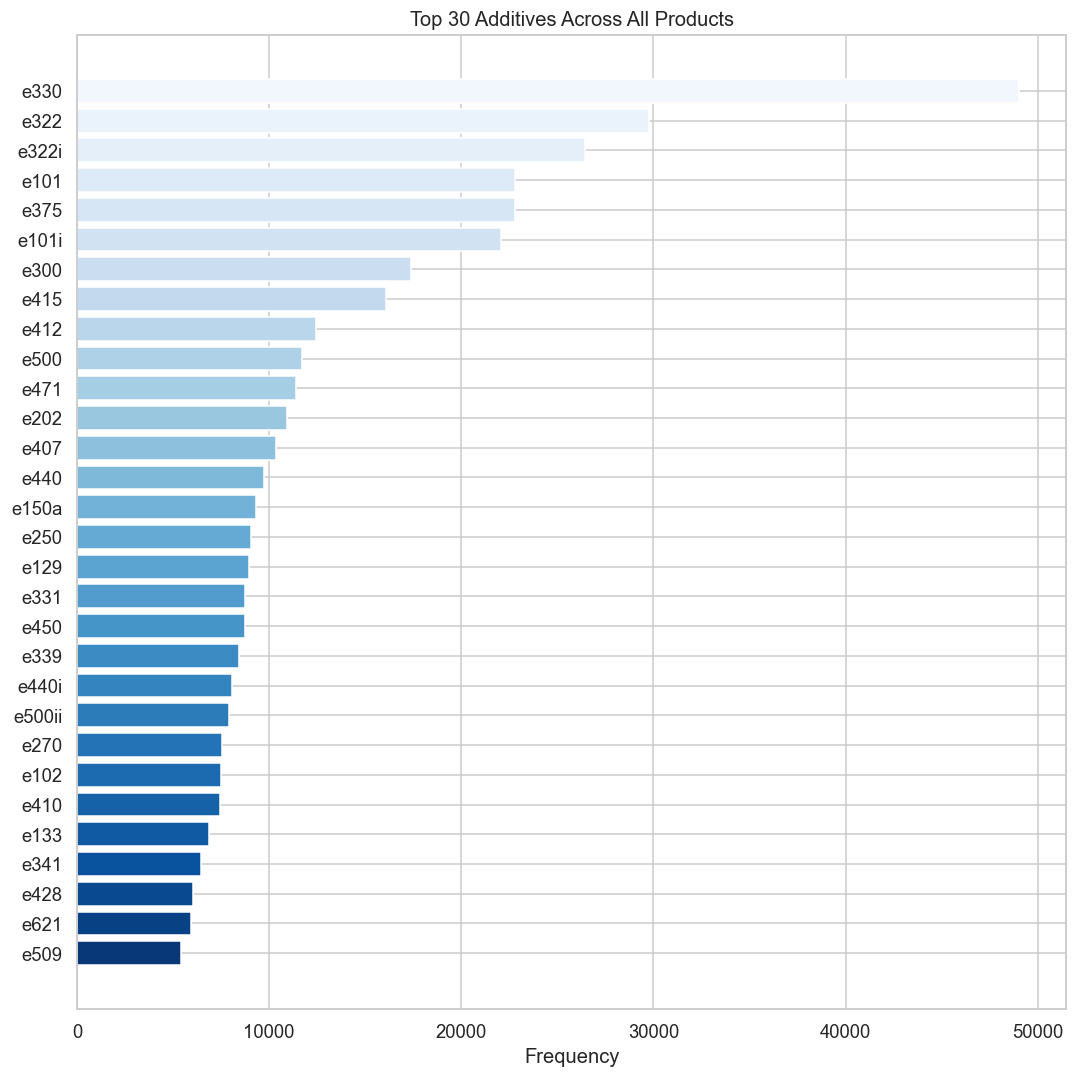

In [58]:
if "additives_tags" in df.columns:
    additive_series = (
        df["additives_tags"]
        .dropna()
        .str.split(",")
        .explode()
        .str.strip()
        .str.replace(r"^en:", "", regex=True)
        .replace("", np.nan)
        .dropna()
    )
    top_additives = additive_series.value_counts().head(30)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.barh(top_additives.index[::-1], top_additives.values[::-1],
            color=sns.color_palette("Blues_r", 30), edgecolor="white")
    ax.set_xlabel("Frequency")
    ax.set_title("Top 30 Additives Across All Products")
    plt.tight_layout()
    plt.show()
else:
    print("additives_tags column not available.")


## 8. Feature Relationships with Nutritional Quality


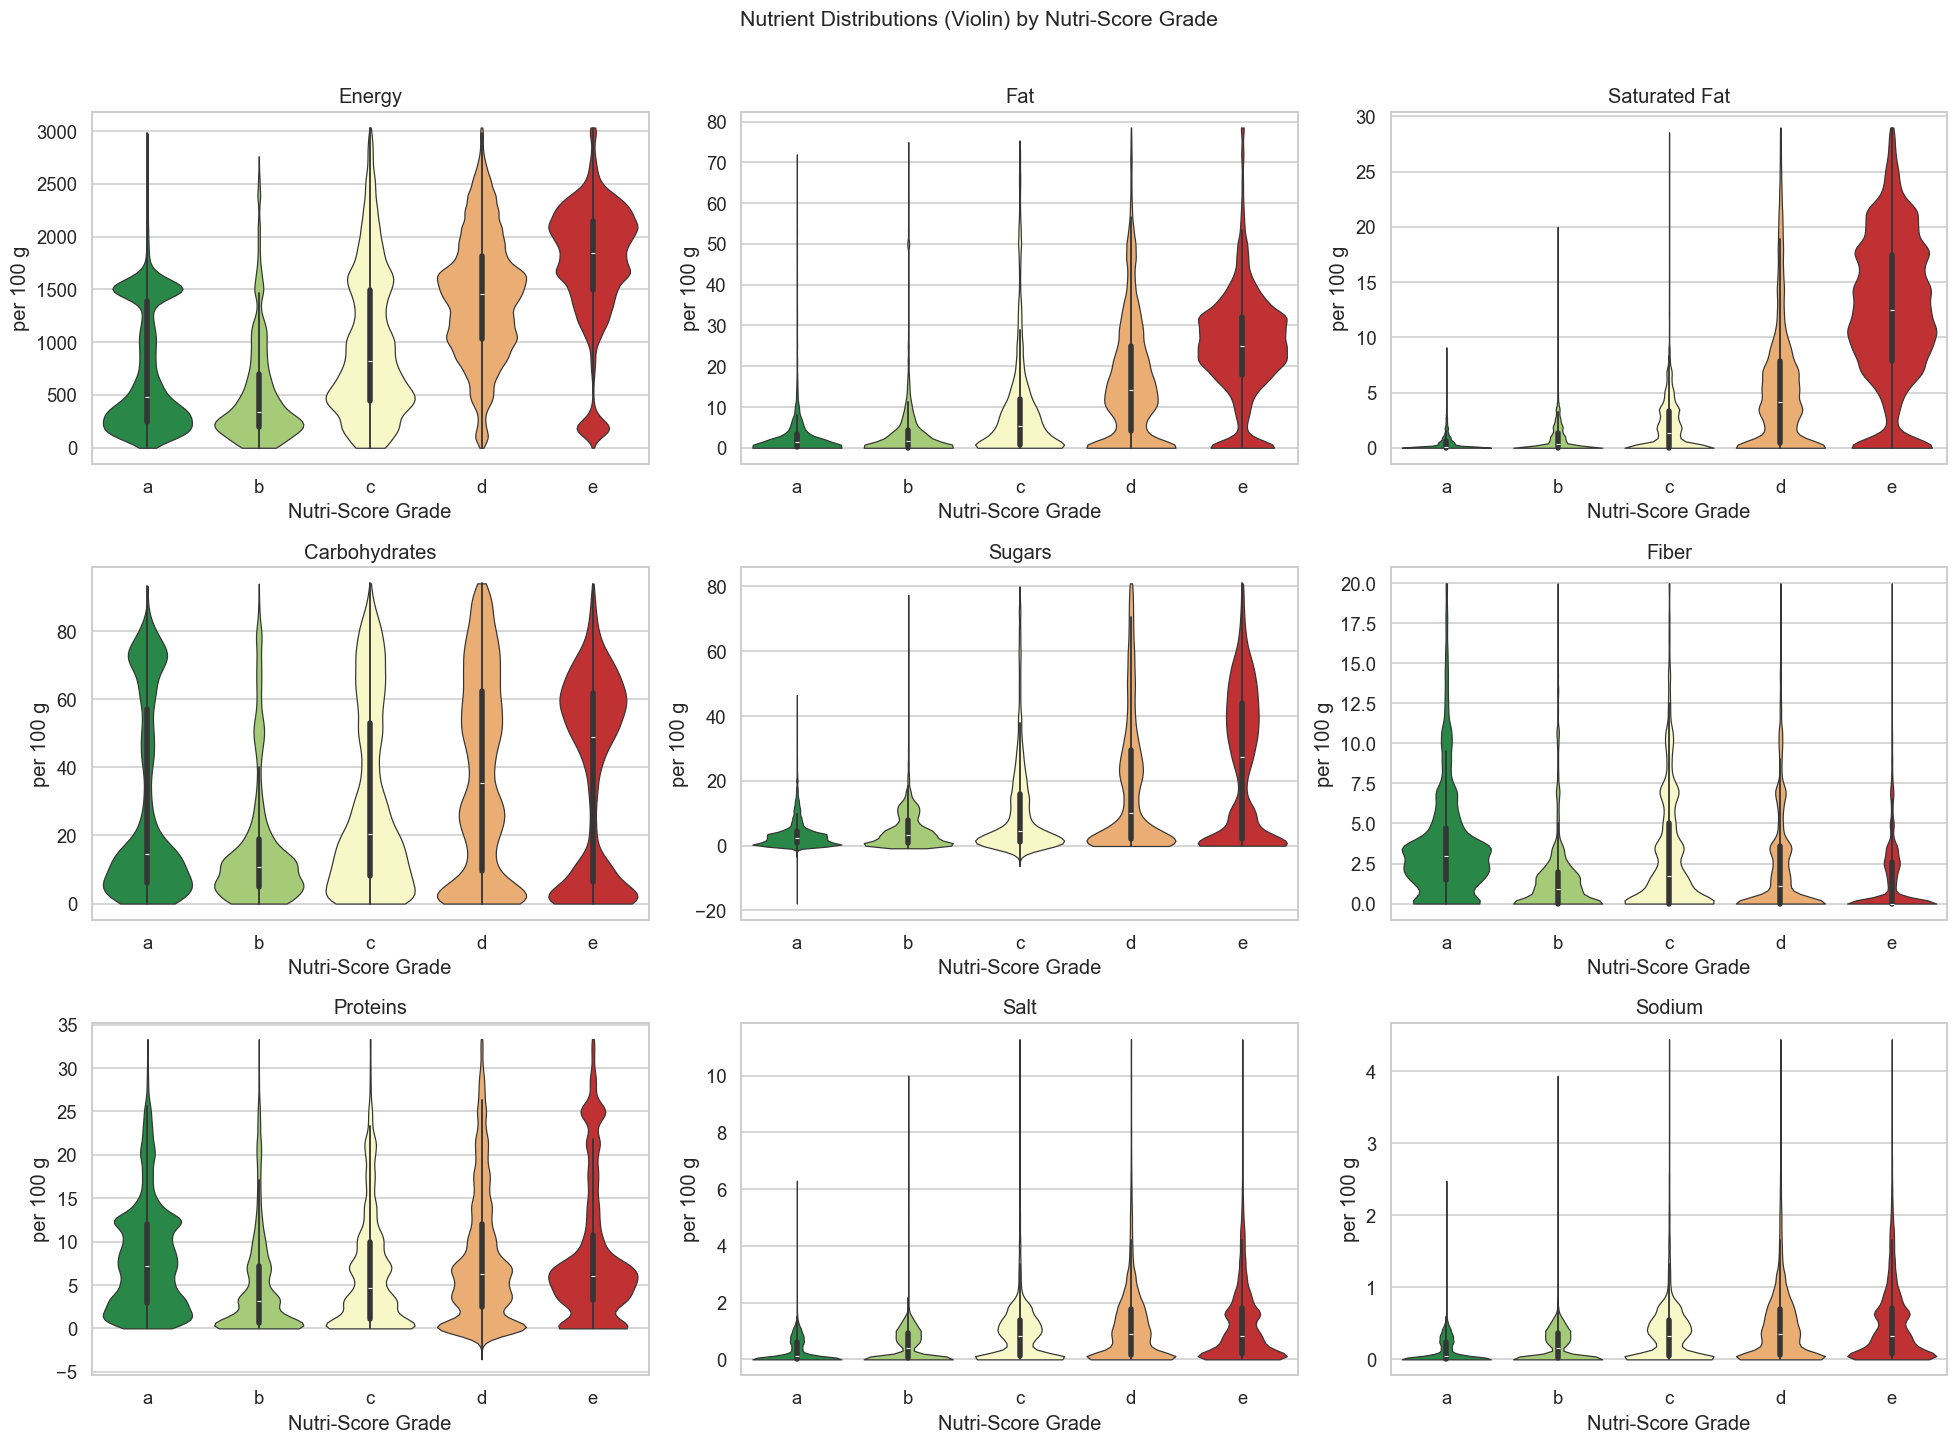

In [59]:
nutriscore_df = df[df["nutrition_grade_fr"].notna()].copy()
nutriscore_df["nutrition_grade_fr"] = nutriscore_df["nutrition_grade_fr"].str.lower()

fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.ravel()

for i, col in enumerate(NUTRIENT_COLS):
    upper = nutriscore_df[col].quantile(0.99)
    plot_data = nutriscore_df[nutriscore_df[col] <= upper]
    sns.violinplot(
        data=plot_data, x="nutrition_grade_fr", y=col, order=["a", "b", "c", "d", "e"],
        palette=dict(zip(["a", "b", "c", "d", "e"],
                         ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"])),
        cut=0, linewidth=0.8, ax=axes[i],
    )
    axes[i].set_title(col.replace("_100g", "").replace("-", " ").title())
    axes[i].set_xlabel("Nutri-Score Grade")
    axes[i].set_ylabel("per 100 g")

plt.suptitle("Nutrient Distributions (Violin) by Nutri-Score Grade", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


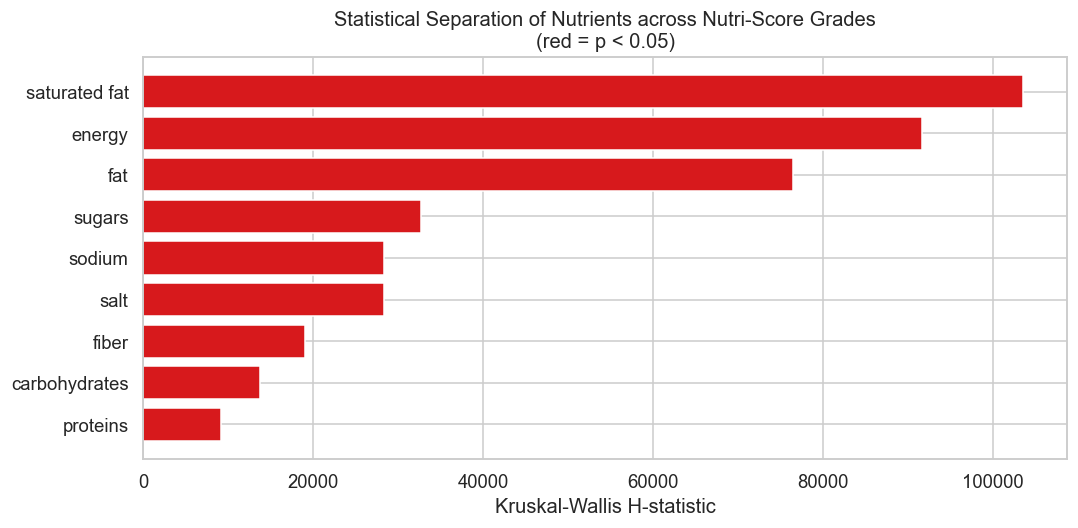

,feature,H-statistic,p-value
2,saturated-fat_100g,103630.500,0.000
0,energy_100g,91657.200,0.000
1,fat_100g,76505.700,0.000
4,sugars_100g,32731.300,0.000
8,sodium_100g,28408.300,0.000
7,salt_100g,28407.800,0.000
5,fiber_100g,19002.000,0.000
3,carbohydrates_100g,13744.600,0.000
6,proteins_100g,9195.100,0.000


In [60]:
nutriscore_df = df[df["nutrition_grade_fr"].notna()].copy()
nutriscore_df["nutrition_grade_fr"] = nutriscore_df["nutrition_grade_fr"].str.lower()

kw_results = []
for col in NUTRIENT_COLS:
    groups = [
        nutriscore_df.loc[nutriscore_df["nutrition_grade_fr"] == g, col].dropna().values
        for g in ["a", "b", "c", "d", "e"]
    ]
    groups = [g for g in groups if len(g) > 1]
    if len(groups) >= 2:
        stat, p = stats.kruskal(*groups)
        kw_results.append({"feature": col, "H-statistic": round(stat, 1), "p-value": p})

kw_df = pd.DataFrame(kw_results).sort_values("H-statistic", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d7191c" if p < 0.05 else "#b0b0b0" for p in kw_df["p-value"]]
ax.barh(
    kw_df["feature"].str.replace("_100g", "").str.replace("-", " "),
    kw_df["H-statistic"],
    color=colors,
    edgecolor="white",
)
ax.set_xlabel("Kruskal-Wallis H-statistic")
ax.set_title("Statistical Separation of Nutrients across Nutri-Score Grades\n(red = p < 0.05)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(kw_df)


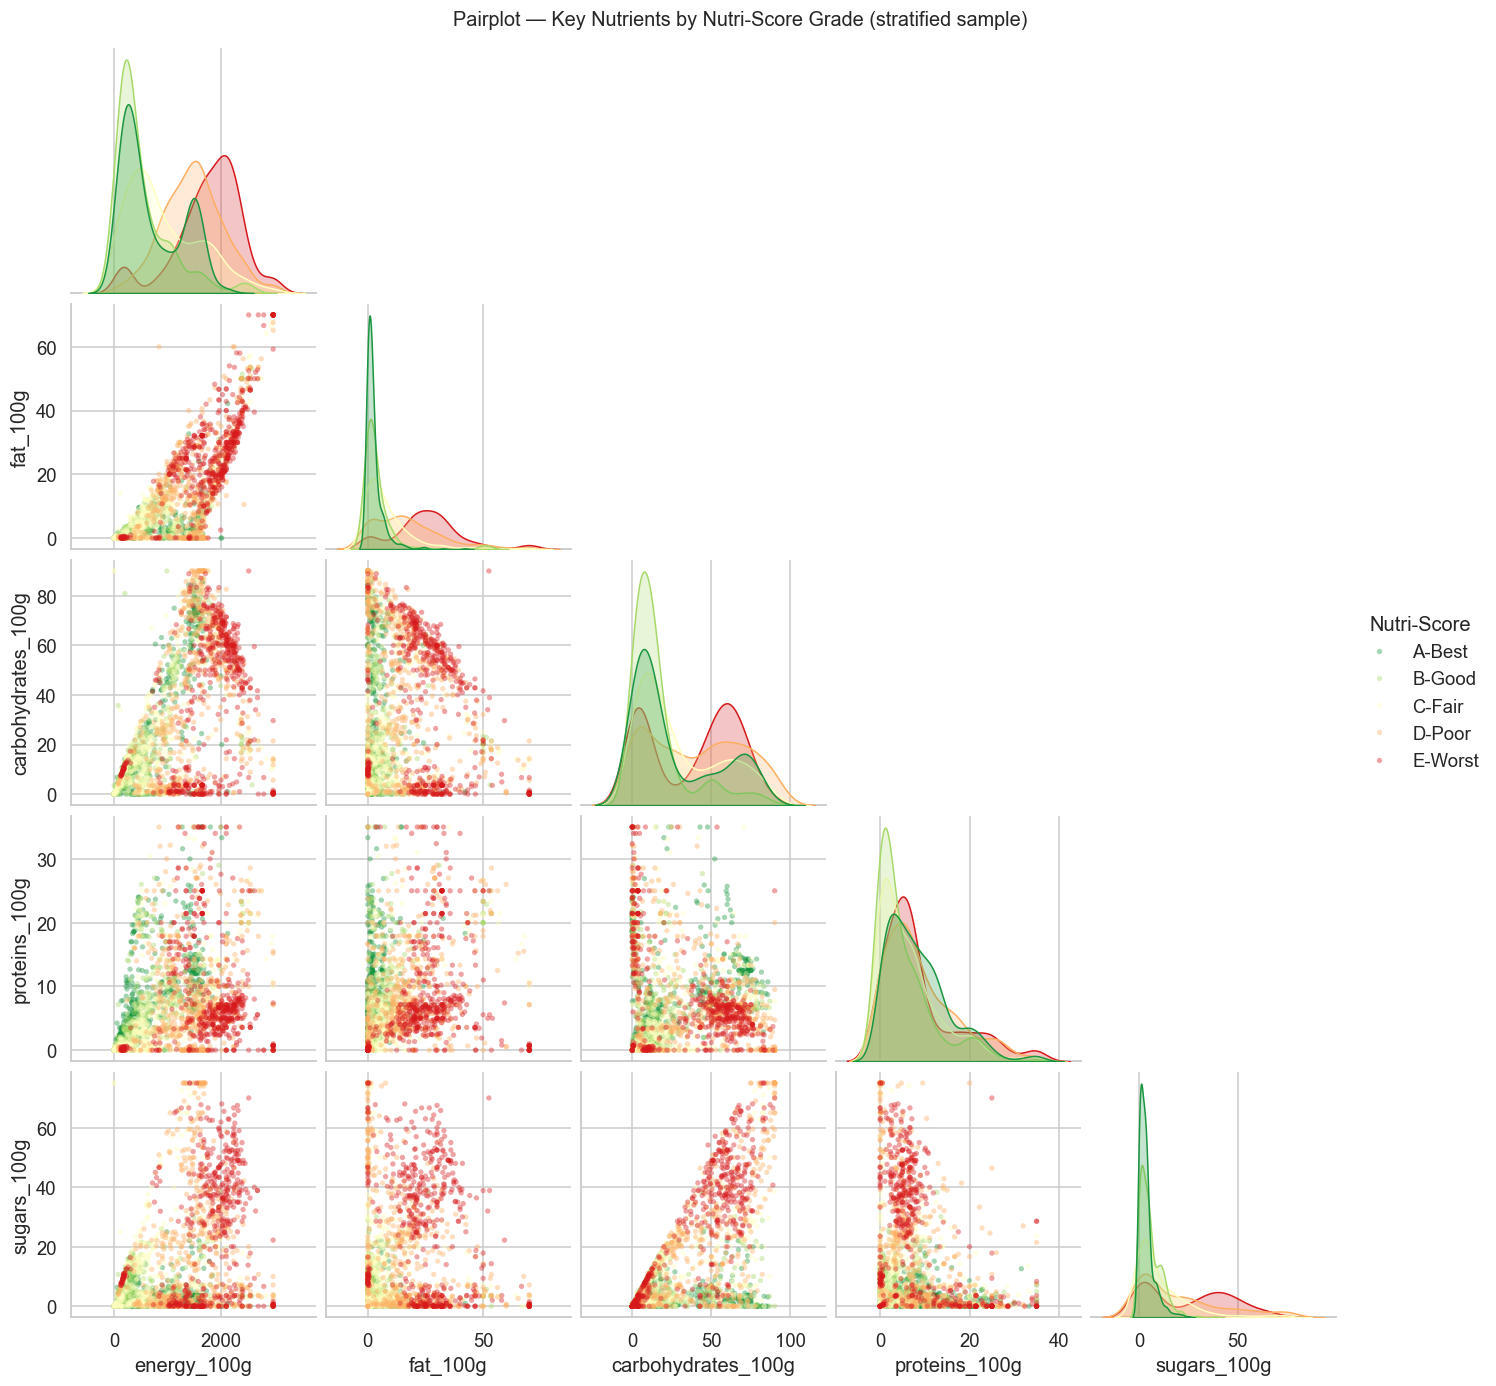

In [61]:
nutriscore_df = df[df["nutrition_grade_fr"].notna()].copy()
nutriscore_df["nutrition_grade_fr"] = nutriscore_df["nutrition_grade_fr"].str.lower()

PAIR_COLS = ["energy_100g", "fat_100g", "carbohydrates_100g", "proteins_100g", "sugars_100g"]

pair_df = (
    nutriscore_df[PAIR_COLS + ["nutrition_grade_fr"]]
    .dropna()
    .groupby("nutrition_grade_fr", group_keys=False)
    .apply(lambda g: g.sample(min(500, len(g)), random_state=42))
)

for c in PAIR_COLS:
    upper = pair_df[c].quantile(0.99)
    pair_df[c] = pair_df[c].clip(upper=upper)

pair_df["Nutri-Score"] = pair_df["nutrition_grade_fr"].map({
    "a": "A-Best", "b": "B-Good", "c": "C-Fair", "d": "D-Poor", "e": "E-Worst"
})

pg = sns.pairplot(
    pair_df.drop(columns="nutrition_grade_fr"),
    hue="Nutri-Score",
    palette=dict(zip(["A-Best", "B-Good", "C-Fair", "D-Poor", "E-Worst"],
                     ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"])),
    diag_kind="kde",
    plot_kws={"alpha": 0.4, "edgecolor": "none", "s": 12},
    corner=True,
)
pg.figure.suptitle("Pairplot — Key Nutrients by Nutri-Score Grade (stratified sample)", y=1.01, fontsize=13)
plt.show()


## 9. Outlier Detection

,feature,outliers,outlier_pct
7,salt_100g,1345,0.460
8,sodium_100g,1345,0.460
2,saturated-fat_100g,318,0.120
5,fiber_100g,147,0.070
6,proteins_100g,78,0.030
0,energy_100g,17,0.010
4,sugars_100g,1,0.000
1,fat_100g,1,0.000
3,carbohydrates_100g,2,0.000


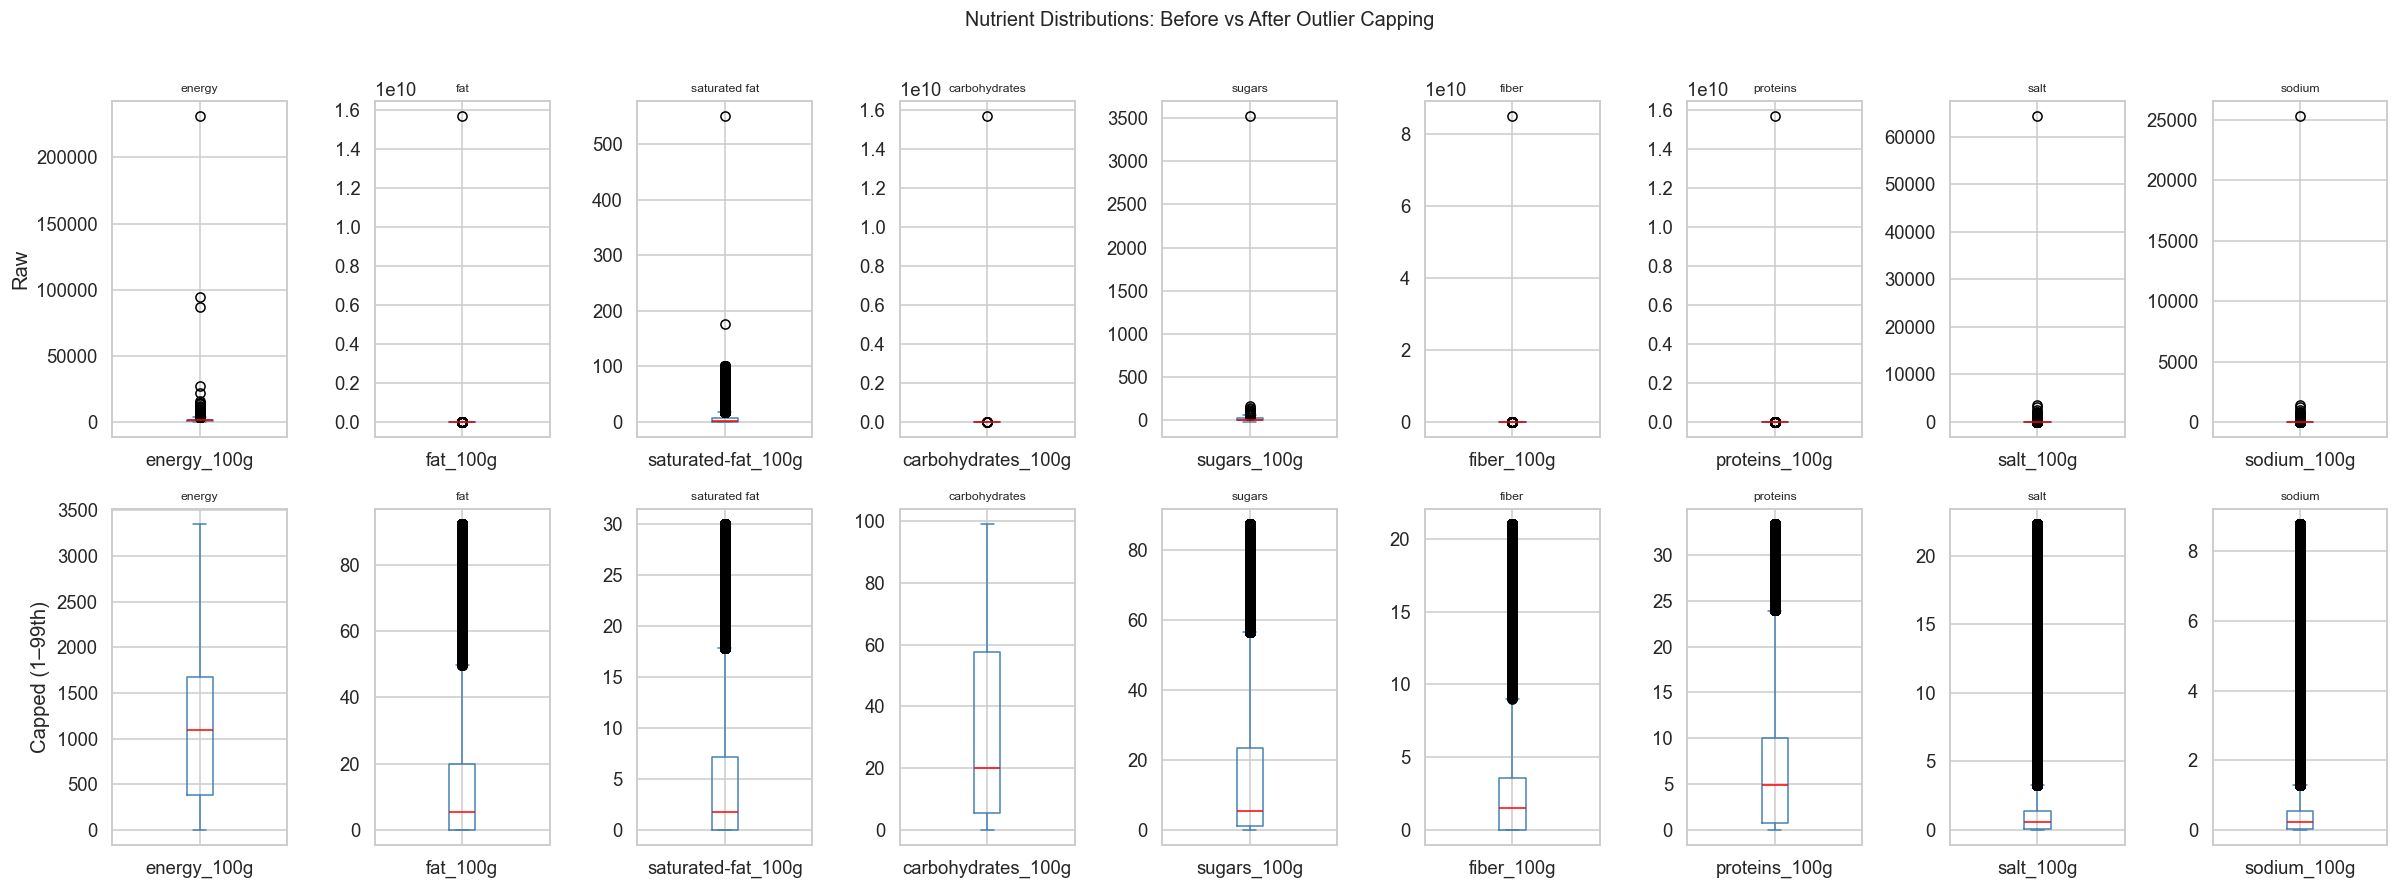

In [ ]:
outlier_summary = []
df_capped = df.copy()

for col in NUTRIENT_COLS:
    q1 = df[col].quantile(0.01)
    q3 = df[col].quantile(0.99)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    pct = n_out / df[col].notna().sum() * 100
    outlier_summary.append({"feature": col, "outliers": n_out, "outlier_pct": round(pct, 2)})
    df_capped[col] = df[col].clip(lower=df[col].quantile(0.01),
                                   upper=df[col].quantile(0.99))

out_df = pd.DataFrame(outlier_summary).sort_values("outlier_pct", ascending=False)
display(out_df)

fig, axes = plt.subplots(2, len(NUTRIENT_COLS), figsize=(22, 8))
for i, col in enumerate(NUTRIENT_COLS):
    label = col.replace("_100g", "").replace("-", " ")
    df[col].dropna().plot.box(ax=axes[0, i], color="steelblue", medianprops={"color": "red"})
    df_capped[col].dropna().plot.box(ax=axes[1, i], color="steelblue", medianprops={"color": "red"})
    axes[0, i].set_title(label, fontsize=8)
    axes[1, i].set_title(label, fontsize=8)

axes[0, 0].set_ylabel("Raw")
axes[1, 0].set_ylabel("Capped (1-99th)")
plt.suptitle("Nutrient Distributions: Before vs After Outlier Capping", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 10. Missing Data Imputation Strategy

Imputation Summary


,feature,global_median,strategy
0,energy_100g,1092.000,global median
1,fat_100g,5.290,global median
2,saturated-fat_100g,1.790,global median
3,carbohydrates_100g,20.000,global median
4,sugars_100g,5.400,global median
5,fiber_100g,1.500,global median
6,proteins_100g,4.880,global median
7,salt_100g,0.559,global median
8,sodium_100g,0.220,global median


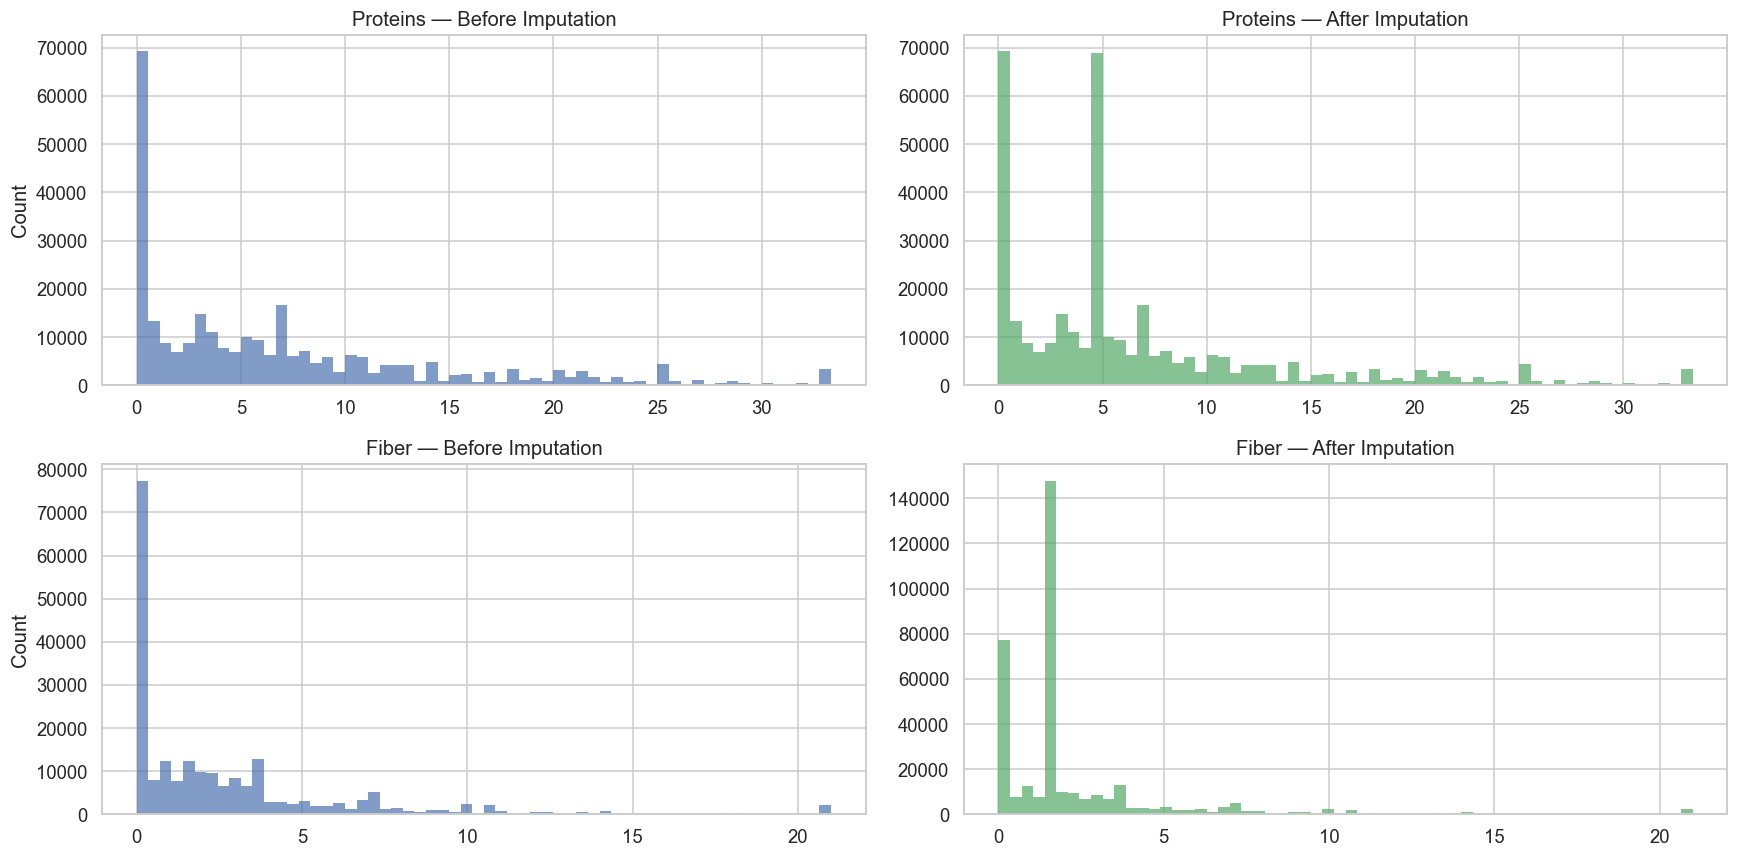

In [63]:
df_imp = df_capped.copy()

imputation_log = []
for col in NUTRIENT_COLS:
    global_med = df_imp[col].median()
    df_imp[col] = df_imp[col].fillna(global_med)
    
    imputation_log.append({
        "feature"       : col,
        "global_median" : round(global_med, 3),
        "strategy"      : "global median",
    })

imp_df = pd.DataFrame(imputation_log)
print("Imputation Summary")
display(imp_df)

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
compare_cols = ["proteins_100g", "fiber_100g"]

for col, (ax_r, ax_i) in zip(compare_cols, [(axes[0, 0], axes[0, 1]), (axes[1, 0], axes[1, 1])]):
    raw   = df_capped[col].dropna()
    imp   = df_imp[col]
    label = col.replace("_100g", "").replace("-", " ").title()
    upper = raw.quantile(0.99)
    ax_r.hist(raw[raw <= upper], bins=60, color="#4C72B0", alpha=0.7, edgecolor="none")
    ax_r.set_title(f"{label} — Before Imputation")
    ax_r.set_ylabel("Count")
    ax_i.hist(imp[imp <= upper], bins=60, color="#55A868", alpha=0.7, edgecolor="none")
    ax_i.set_title(f"{label} — After Imputation")

plt.tight_layout()
plt.show()


## 11. Geographic and Category Distribution

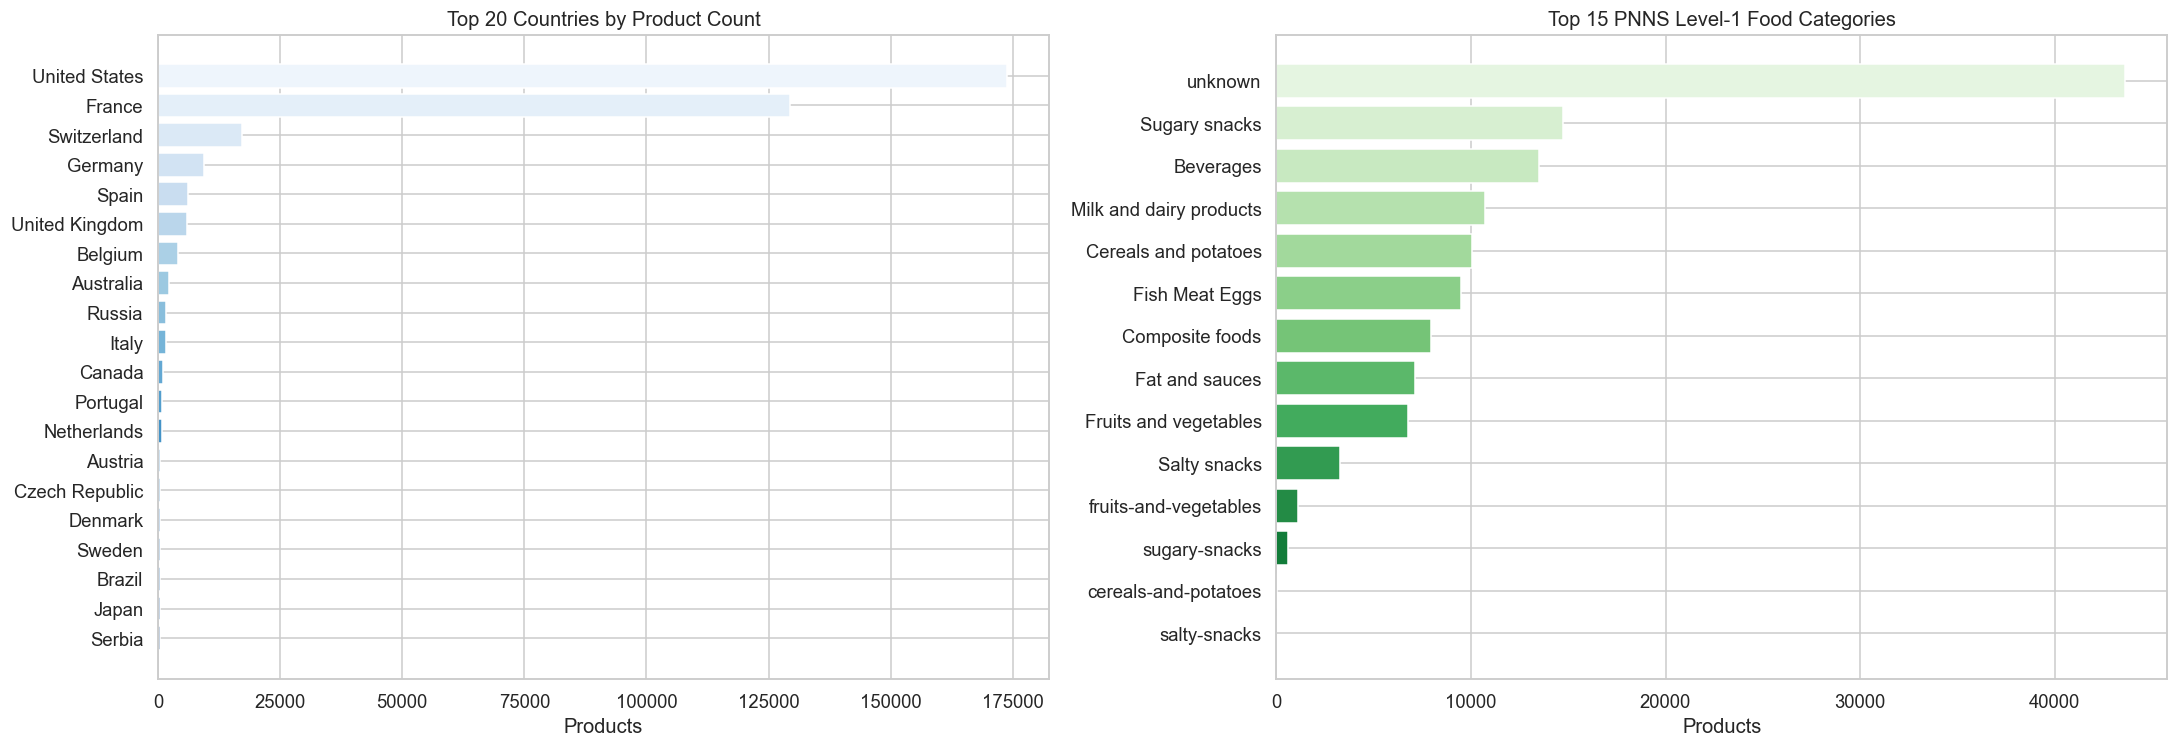

In [64]:
country_counts = (
    df["countries_en"]
    .str.split(",")
    .explode()
    .str.strip()
    .value_counts()
    .head(20)
)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

axes[0].barh(country_counts.index[::-1], country_counts.values[::-1],
             color=sns.color_palette("Blues_r", 20), edgecolor="white")
axes[0].set_xlabel("Products")
axes[0].set_title("Top 20 Countries by Product Count")

cat_counts = df["pnns_groups_1"].value_counts().dropna().head(15)
axes[1].barh(cat_counts.index[::-1], cat_counts.values[::-1],
             color=sns.color_palette("Greens_r", 15), edgecolor="white")
axes[1].set_xlabel("Products")
axes[1].set_title("Top 15 PNNS Level-1 Food Categories")

plt.tight_layout()
plt.show()


## 12. Nutritional Profile Clustering Preview (PCA + KMeans)

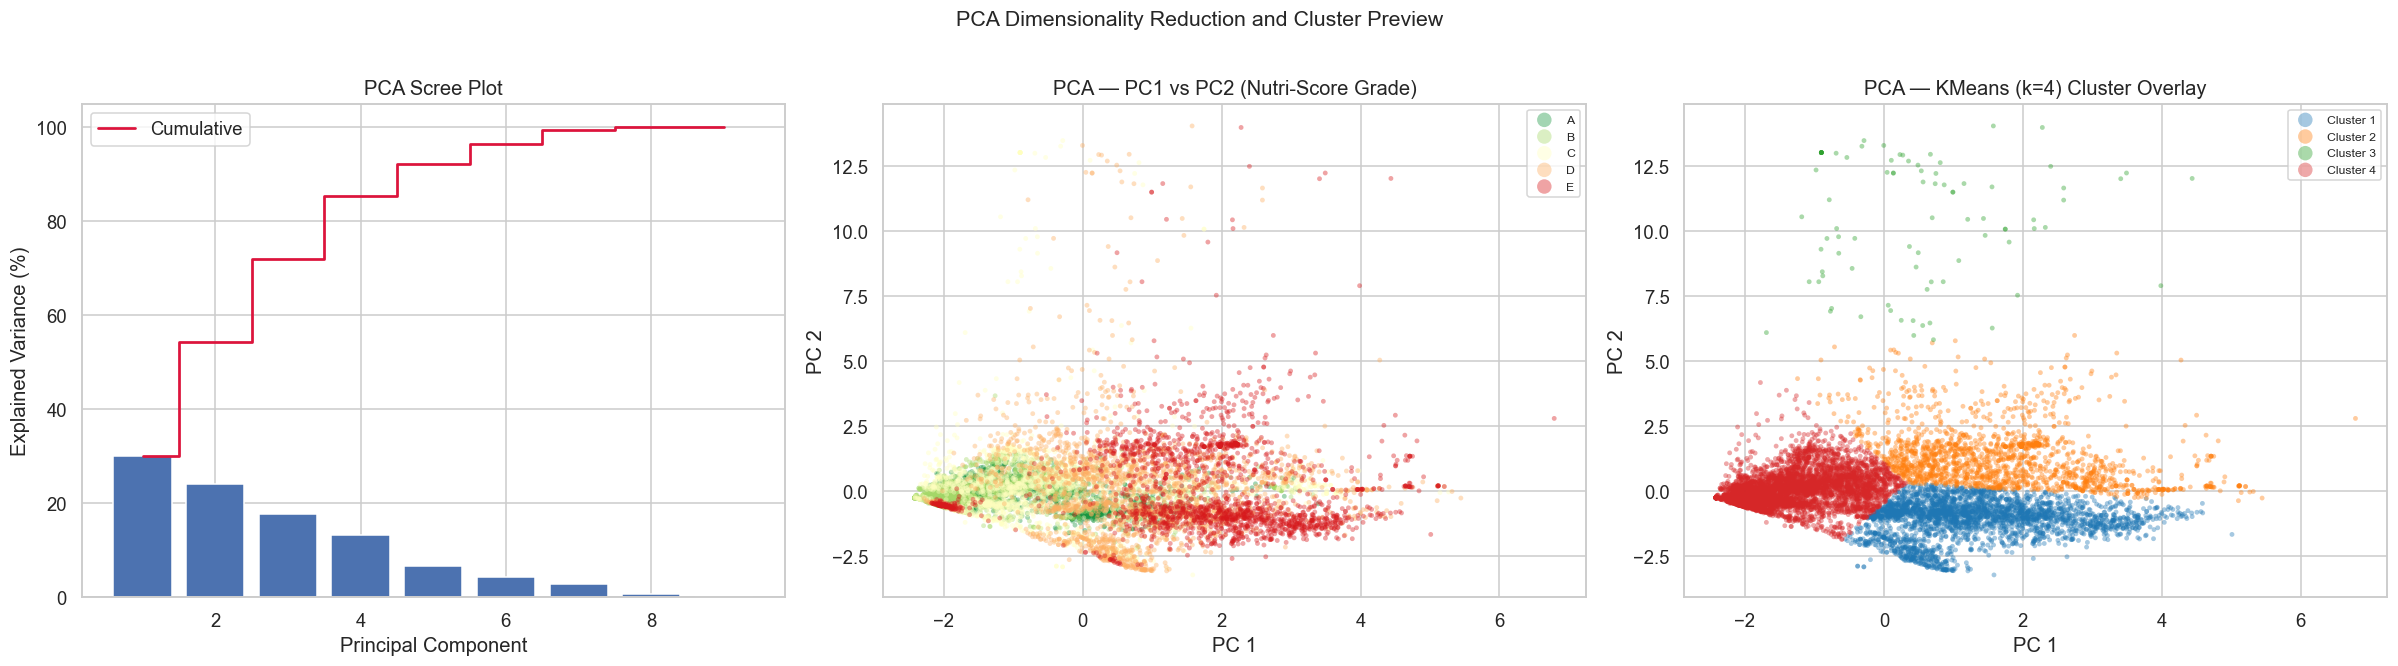

Variance explained by PC1+PC2: 54.3%


In [65]:
pca_df = df_imp[NUTRIENT_COLS + ["nutrition_grade_fr"]].dropna(subset=["nutrition_grade_fr"])
pca_df = pca_df.dropna(subset=NUTRIENT_COLS)
pca_df["nutrition_grade_fr"] = pca_df["nutrition_grade_fr"].str.lower()

pca_sample = (
    pca_df.groupby("nutrition_grade_fr", group_keys=False)
          .apply(lambda g: g.sample(min(2000, len(g)), random_state=42))
)
X       = pca_sample[NUTRIENT_COLS].values
y_nutri = pca_sample["nutrition_grade_fr"].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca   = PCA(n_components=min(len(NUTRIENT_COLS), 9), random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100, color="#4C72B0", edgecolor="white")
axes[0].step(range(1, len(pca.explained_variance_ratio_) + 1),
             np.cumsum(pca.explained_variance_ratio_) * 100, where="mid",
             color="crimson", linewidth=1.8, label="Cumulative")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("PCA Scree Plot")
axes[0].legend()

for grp, color in zip(["a", "b", "c", "d", "e"],
                      ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d7191c"]):
    mask = y_nutri == grp
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], alpha=0.4,
                    s=10, edgecolors="none", label=grp.upper())
axes[1].set_title("PCA — PC1 vs PC2 (Nutri-Score Grade)")
axes[1].legend(markerscale=3, fontsize=8)
axes[1].set_xlabel("PC 1")
axes[1].set_ylabel("PC 2")

km        = KMeans(n_clusters=4, random_state=42, n_init=10)
km_labels = km.fit_predict(X_pca[:, :2])
km_palette = sns.color_palette("tab10", 4)
for k in range(4):
    mask = km_labels == k
    axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], c=[km_palette[k]],
                    alpha=0.4, s=10, edgecolors="none", label=f"Cluster {k + 1}")
axes[2].set_xlabel("PC 1")
axes[2].set_ylabel("PC 2")
axes[2].set_title("PCA — KMeans (k=4) Cluster Overlay")
axes[2].legend(markerscale=3, fontsize=8)

plt.suptitle("PCA Dimensionality Reduction and Cluster Preview", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_[:2].sum() * 100:.1f}%")
